In [15]:

import matplotlib.pyplot as plt
import networkx as nx
from nltk.corpus import wordnet as wn
import textacy



Se plantean diferentes ejercicios sobre ontologías y su representación visual por medio
de grafos.
Las ontologías son un tipo de representación estructurada del conocimiento donde los
conceptos se organizan y relacionan entre sí. A menudo, las ontologías se representan
visualmente por medio de grafos, donde cada nodo corresponde a un concepto y las
aristas representan las relaciones existentes entre dichos conceptos.



# Ejercicio 1

1. WordNet es un recurso léxico que agrupa palabras en conjuntos de synsets,
definiendo relaciones semánticas y jerárquicas entre ellos. Aunque no presenta
todas las características formales de una ontología léxica en sentido estricto,
comparte numerosas características fundamentales con ellas.
Se quiere visualizar gráficamente la relación entre el primer synset de la palabra
“dog” (dog.n.01) y sus correspondientes hipónimos. Para ello, se usarán las librerías
NetworkX y Matplotlib:
- NetworkX es una biblioteca de Python para el estudio de grafos y análisis de
redes.
- Matplotlib es una librería Python open source que permite crear visualizaciones
de datos.
A continuación, se proporciona un código de ejemplo que muestra un grafo en el
que hay 4 nodos (n1, n2, n3 y n4) y relaciones entre ellos (n1 -r1-> n2, n2 -r2-> n3,
n4 -r3 -> n3)

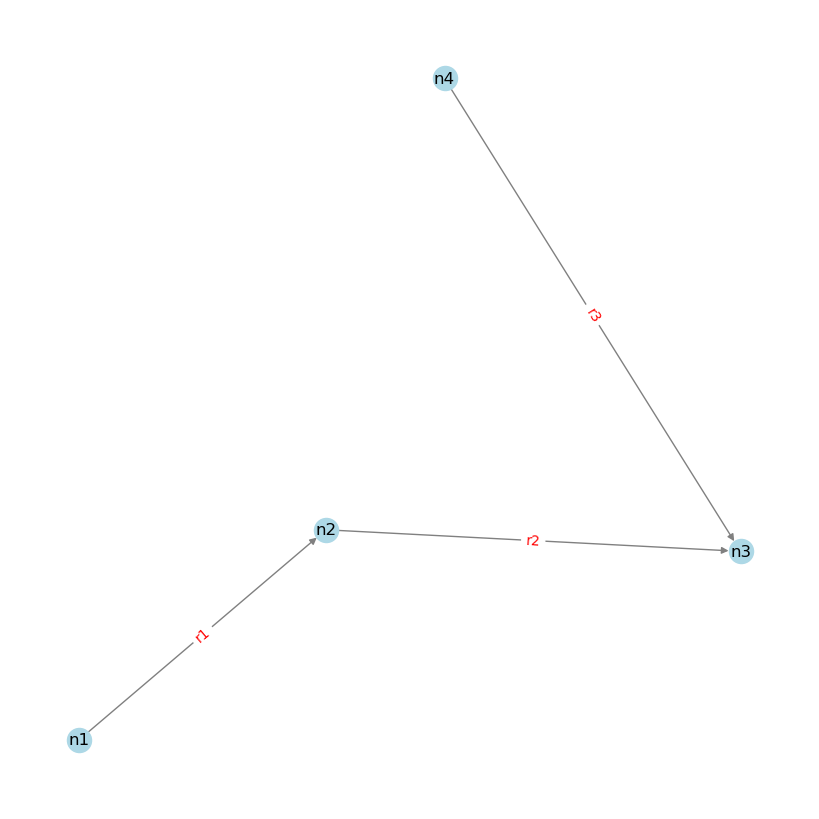

In [29]:
G= nx.DiGraph()
G.add_edge('n1','n2', label='r1')
G.add_edge('n2','n3', label='r2')
G.add_edge('n4','n3', label='r3')

plt.figure(figsize=(8,8))

pos= nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
edge_labels= nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)

plt.show()



# Ejercicio 2

En WordNet, las relaciones de hiperonimia e hiponimia no están limitadas a un solo
nivel jerárquico. Esto implica que, a partir de un concepto de partida, no solo es
posible identificar sus relaciones directas, sino también las relaciones a niveles
sucesivos. Es decir, además de poder obtener los hiperónimos de un concepto (como
dog.n.01), podemos seguir explorando y obtener los hipónimos de sus propios
hipónimos.
En este ejercicio, se desea recorrer recursivamente y visualizar con NetworkX todos
los hiperónimos a partir del primer synset de la palabra “dog” (dog.n.01), mostrando
una jerarquía completa de conceptos ascendentes. Reflexionar sobre la utilidad que
estas relaciones y jerarquías pueden ofrecer en diversos casos de uso de PLN.
Para mejorar la visualización del grafo, se recomienda cambiar el layout al siguiente:
pos = nx.kamada_kawai_layout(G)


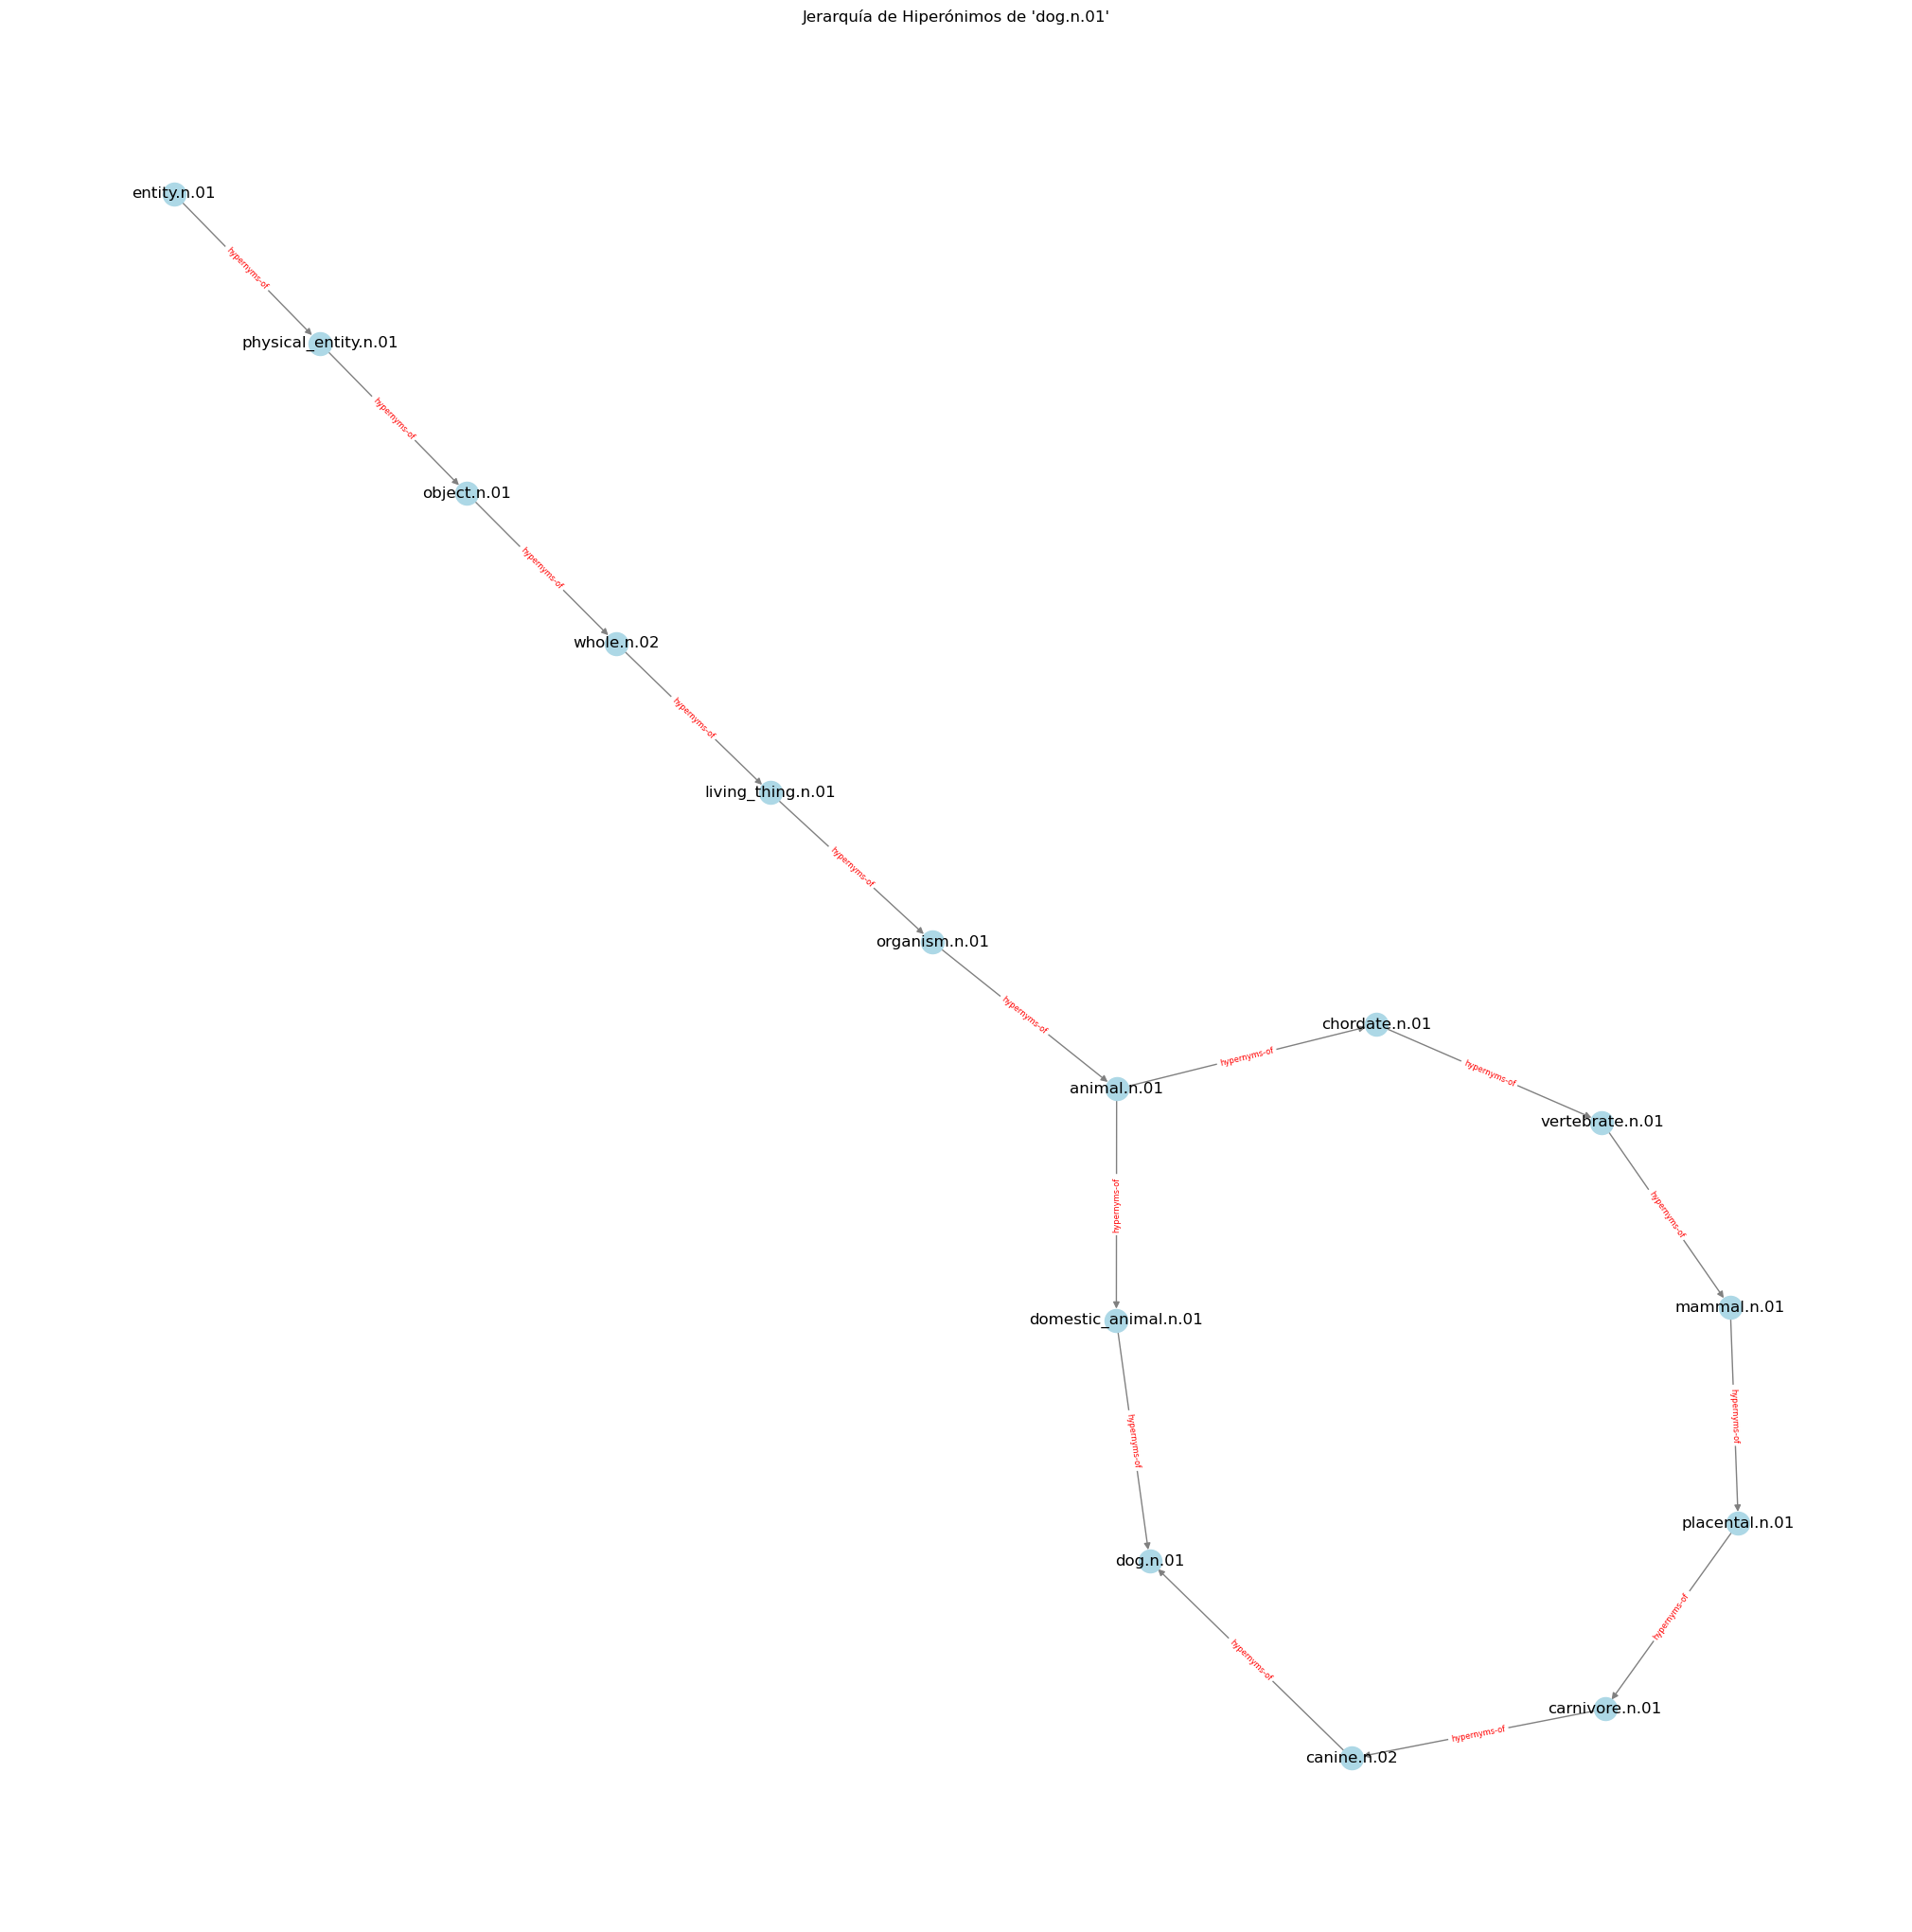

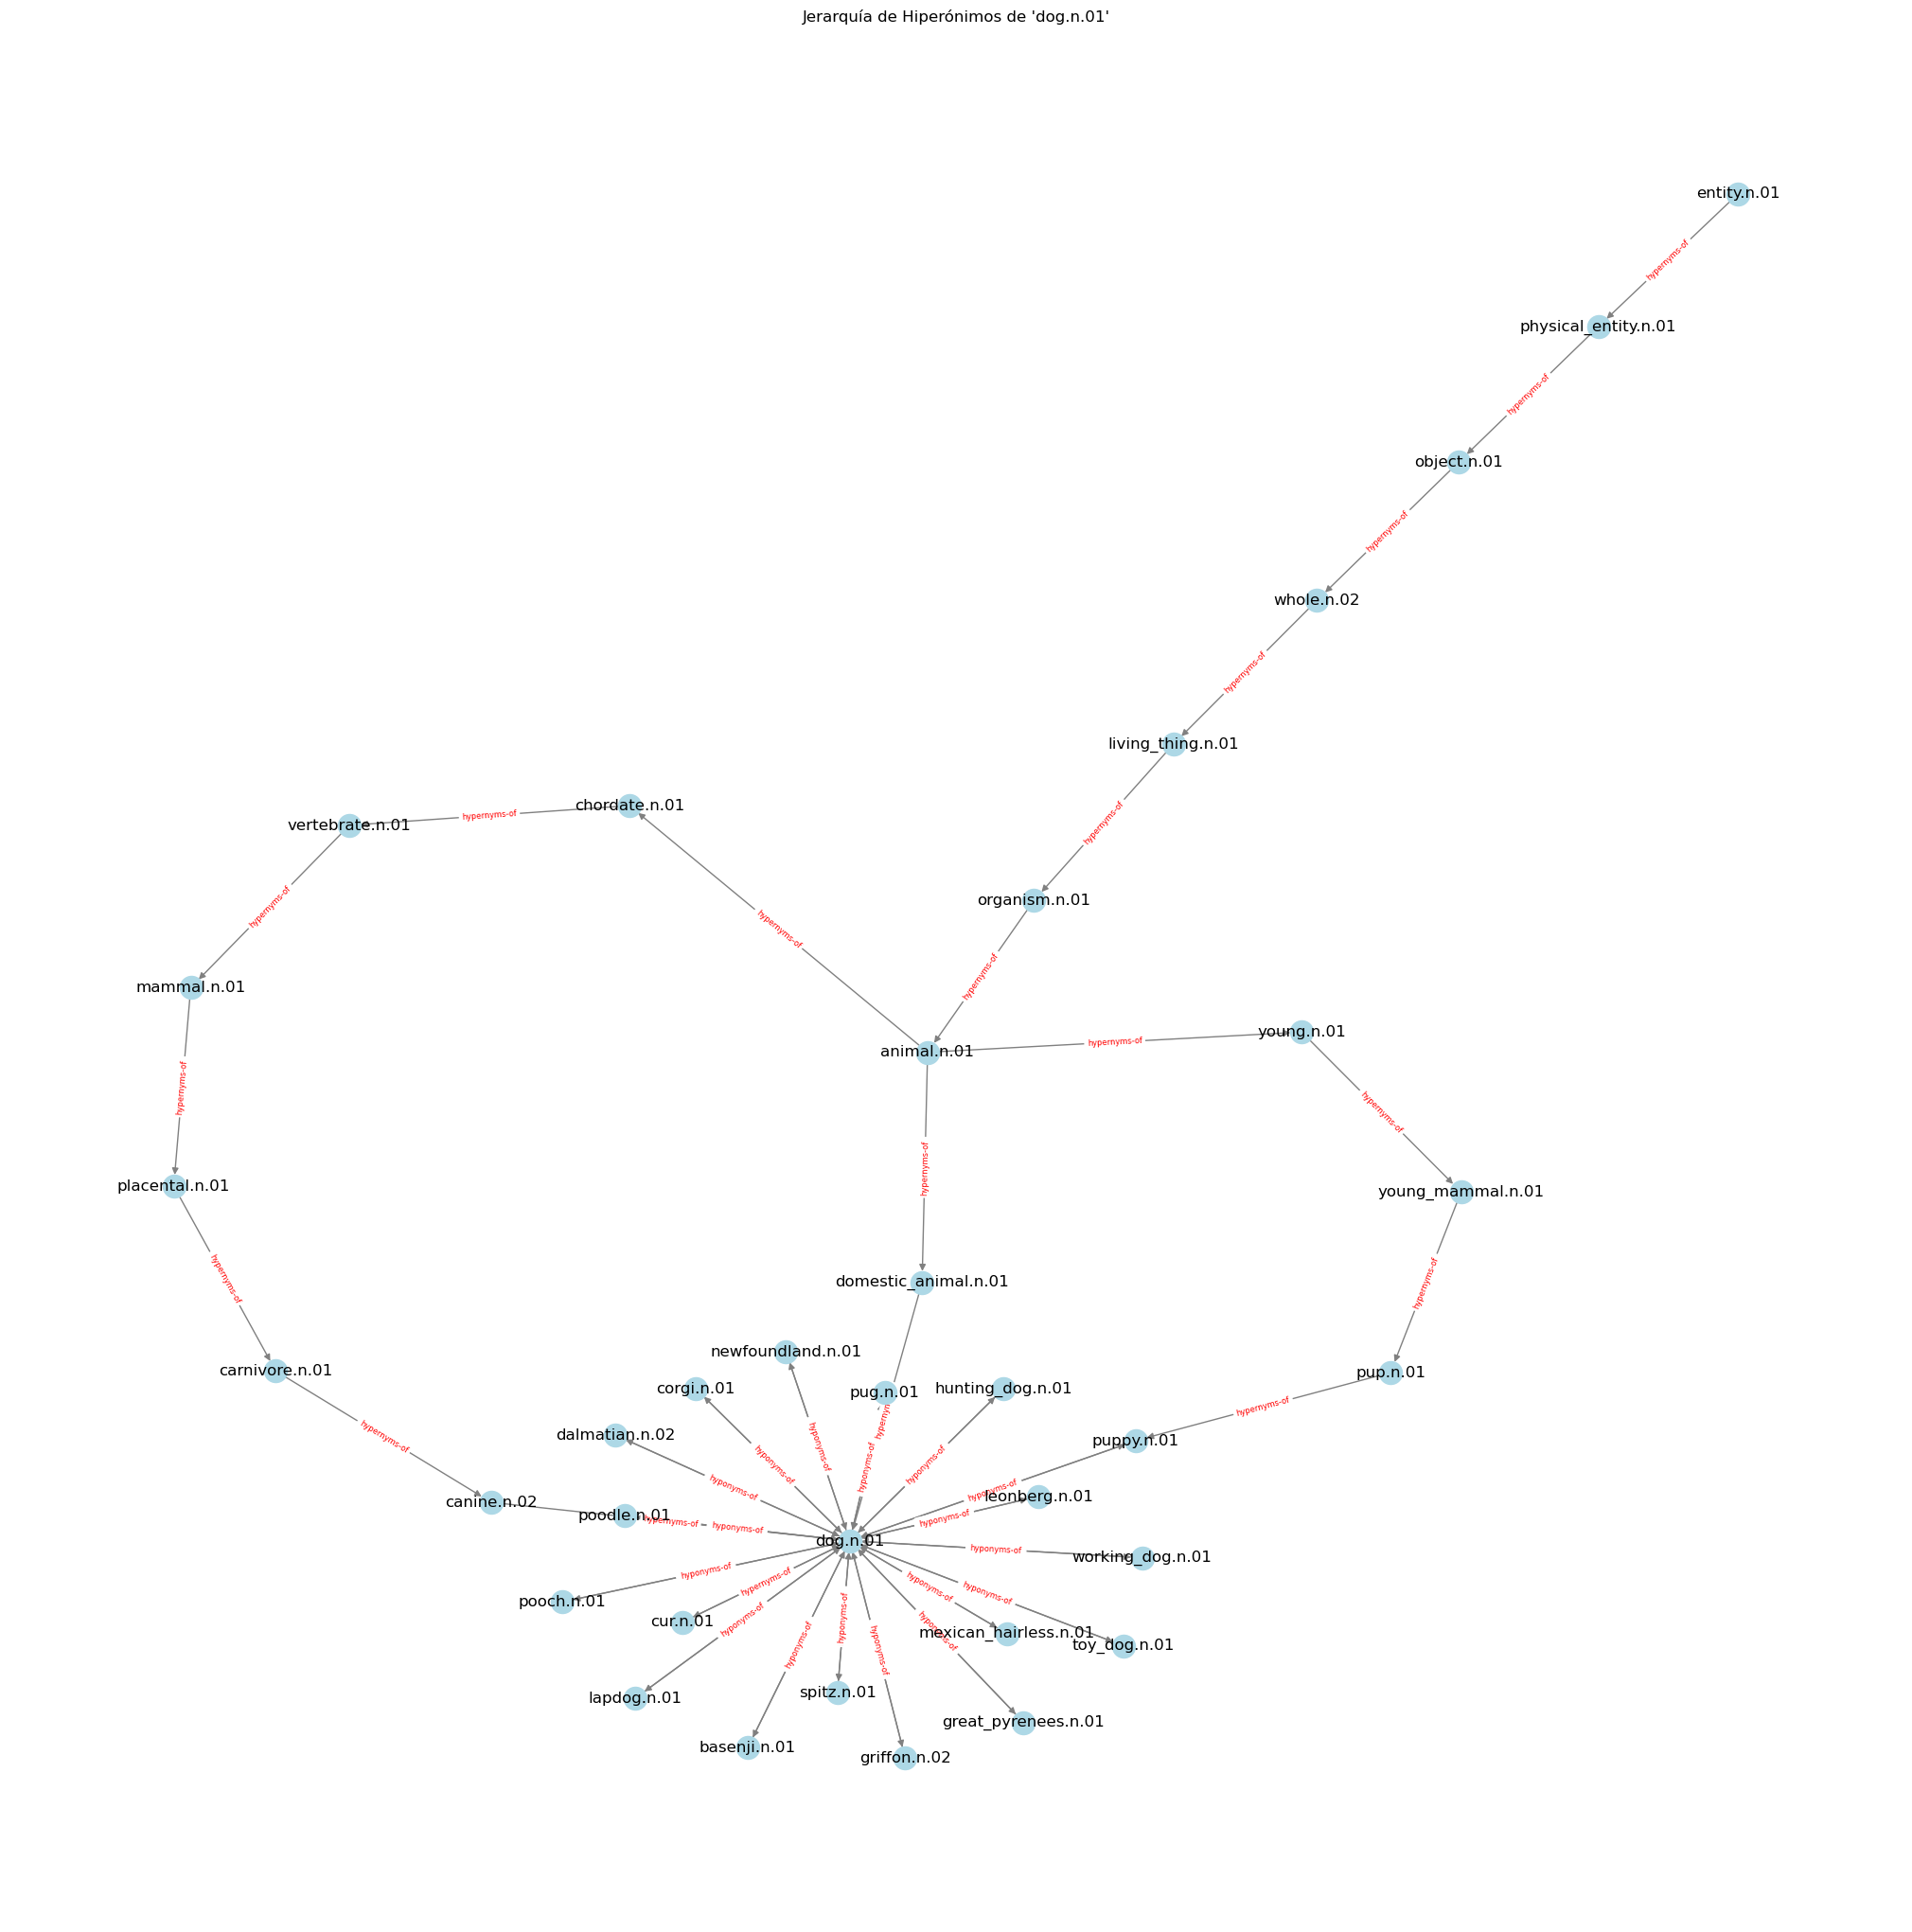

In [33]:

def add_hypernyms(G, synset):
    for h in synset.hypernyms():
        G.add_node(h.name())
        G.add_edge(h.name(), synset.name(), label="hypernyms-of")
        add_hypernyms(G, h)


word='dog'
synset = wn.synsets(word)[0]
G= nx.DiGraph()
add_hypernyms(G, synset)

plt.figure(figsize=(20,20))
pos= nx.kamada_kawai_layout(G)
nx.draw(G, pos,with_labels=True, node_color='lightblue', edge_color='gray')
edge_labels=nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=6)
plt.title("Jerarquía de Hiperónimos de 'dog.n.01'")
plt.show()


def add_hyponyms(G, synset):
    for h in synset.hyponyms():
        G.add_node(h.name())
        G.add_edge(h.name(), synset.name(), label="hyponyms-of")
        add_hypernyms(G, h)

word='dog'
synset = wn.synsets(word)[0]
G= nx.DiGraph()
add_hyponyms(G, synset)

plt.figure(figsize=(20,20))
pos= nx.kamada_kawai_layout(G)
nx.draw(G, pos,with_labels=True, node_color='lightblue', edge_color='gray')
edge_labels=nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=6)
plt.title("Jerarquía de Hipónimos de 'dog.n.01'")
plt.show()



# Ejercicio 3 

Las tripletas SVO (Sujeto-Verbo-Objeto) son una forma de fragmentar una frase en
sus tres partes principales: Sujeto (entidad que realiza la acción), Verbo (la acción
que se realiza) y Objeto (la entidad que recibe la acción). Estas tripletas proporcionan
una manera sencilla de estructurar las diferentes frases que componen los
documentos de un corpus, pudiendo ser un punto de partida para la creación de
relaciones y grafos semánticos.
a. Se desean extraer las tripletas SVO del siguiente conjunto de frases:
Tema 2 - Procesamiento del Lenguaje Natural I
(Grado en Inteligencia Artificial)
Natalia Madrueño y Soto Montalvo 3
- Jack eats pizza.
- Jack reads a book.
- Alice sells pizza.
- Bob writes a book.
Para ello, se recomienda usar textacy, librería construida sobre spaCy que extiende
sus funcionalidades. En particular, se recomienda emplear la función
textacy.extract.subject_verb_object_triples(doc) de dicha librería, la cual recibe
como entrada un objeto Doc de spaCy.
Nota: textacy

[SVOTriple(subject=[Jack], verb=[eats], object=[pizza])]
[SVOTriple(subject=[Jack], verb=[reads], object=[book])]
[SVOTriple(subject=[Alice], verb=[sells], object=[pizza])]
[SVOTriple(subject=[Bob], verb=[writes], object=[book])]


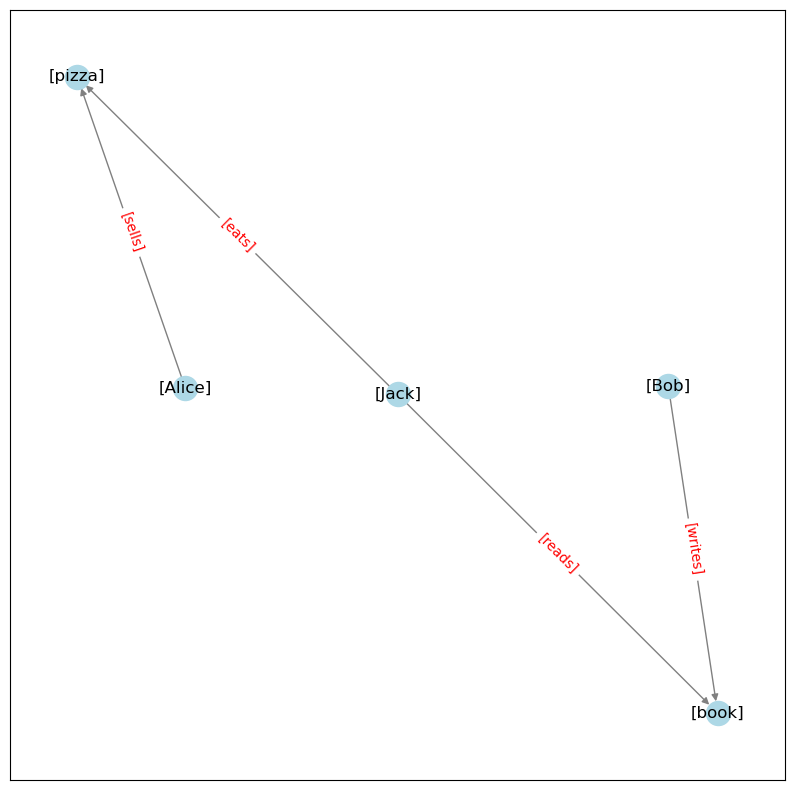

In [53]:
import spacy
frases=[ 'Jack eats pizza.',
         'Jack reads a book.',
         'Alice sells pizza',
         'Bob writes a book.']

nlp = spacy.load("en_core_web_sm")
docs= []
G3 = nx.DiGraph()

for f in frases:
    docs.append(nlp(f))

for doc in docs:
    SVO_tupla=  list(textacy.extract.subject_verb_object_triples(doc))
    print(SVO_tupla)

    for s, v, o in SVO_tupla:
        G3.add_edge(str(s), str(o), label=str(v))

plt.figure(figsize=(10,10))
pos = nx.spring_layout(G3, k=0.5)
nx.draw_networkx(G3, pos, node_color="lightblue", edge_color="gray")
edge_labels = nx.get_edge_attributes(G3, "label")
nx.draw_networkx_edge_labels(G3, pos, edge_labels=edge_labels, font_color="red", font_size=10)
plt.show()


# Ejercicio 4

Utilizando la librería Owlready2 que permite cargar ontologías y manejarlas como si
fueran objetos en Python, se va a consultar información de una ontología de prueba
sobre pizzas.
En primer lugar, hay que cargar la ontología, para ello hay que proporcionar el IRI
donde se encuentra la ontología. Los IRI se utilizan como identificadores para las
ontologías y son como URLs:
Consultar aquí, en la sección “Accessing the content of an ontology” los diferentes
métodos que se podrían aplicar al objeto anterior onto para consultar el contenido
de una ontología.
Se pide lo siguiente:
-  Mostrar el grafo de la ontología. Probar el código que se proporciona
(PizzaOntologyGraph.py)
-  Mostrar las clases de la ontología.
- Mostrar los individuos (las instancias concretas) de la ontología.
-  Se quieren hacer búsquedas sobre la ontología (consultar aquí ejemplos):
- Buscar todas las entidades o conceptos que tenga al final del IRI “Pizza”.
-  Buscar todos los individuos que tengan alguna relación ‘has_topping’ con
otros individuos.

In [59]:
import owlready2
from rdflib import Graph, Namespace, RDF, RDFS
onto = owlready2.get_ontology("http://www.lesfleursdunormal.fr/static/_downloads/pizza_onto.owl").load()

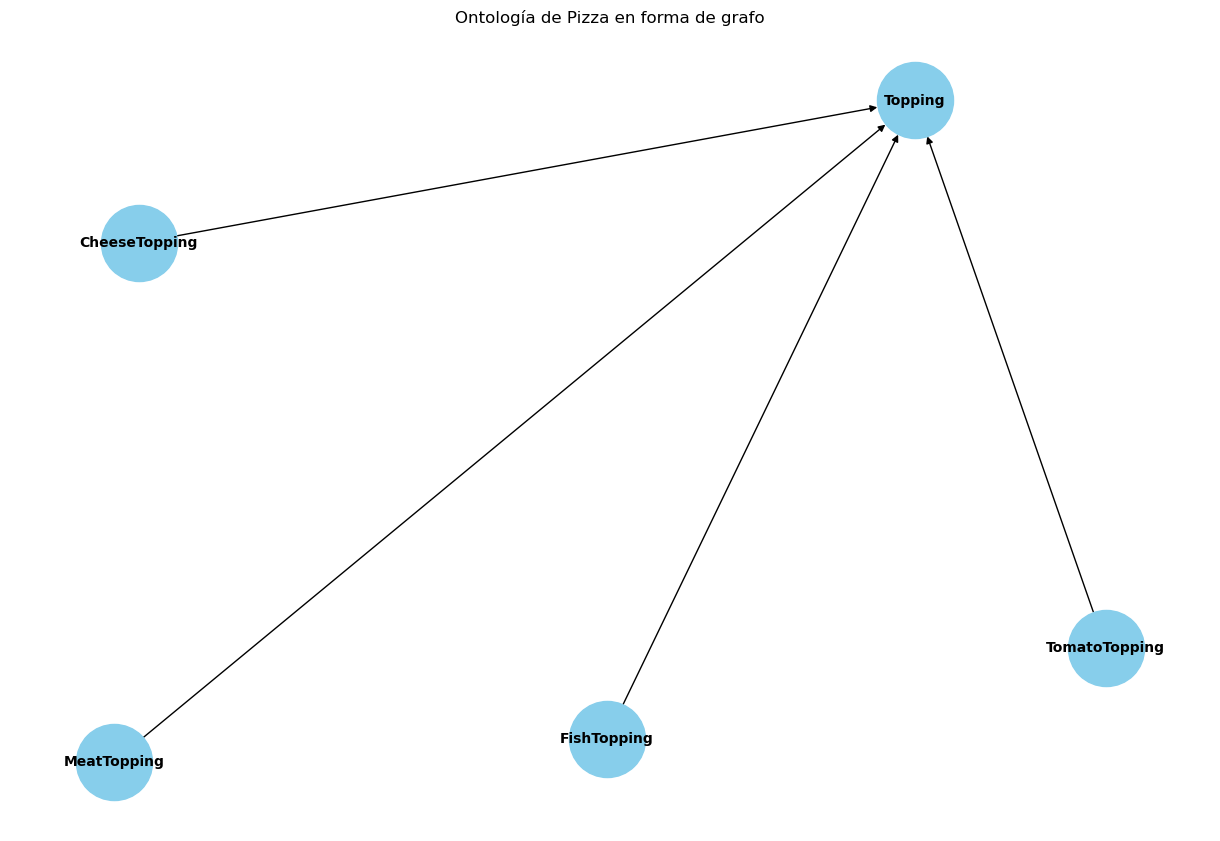

Clases de la ontología:
CheeseTopping
FishTopping
MeatTopping
Pizza
TomatoTopping
Topping
Individuos de la ontología: 


[]

In [68]:
# URL de la ontología
ontology_url = "http://www.lesfleursdunormal.fr/static/_downloads/pizza_onto.owl"

# Cargar la ontología
onto = owlready2.get_ontology(ontology_url).load()
g = onto.world.as_rdflib_graph()

# Crear un grafo de NetworkX
G = nx.DiGraph()

# Añadir nodos y aristas al grafo
for s, p, o in g:
    if p == RDFS.subClassOf:
        G.add_edge(s.split('#')[-1], o.split('#')[-1])

# Dibujar el grafo
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=10, font_weight='bold', arrows=True)
plt.title('Ontología de Pizza en forma de grafo')
plt.show()


# mostrar clases
print("Clases de la ontología:")
for c in onto.classes():
    print(c.name)

#Mostrar individuos
print("Individuos de la ontología: ")

for i in onto.individuals():
    print(i.name)

# Entidades o conceptos que tengan "Pizza" al final de su IRI
onto.search(iri="*Pizza")


# Individuos que tengan alguna relación "has_topping" con otros individuos
onto.search(has_topping = "*")